In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

RAW_DATA_PATH = '../data/heart.csv'


In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print("Data Shape:", df_raw.shape)
print(f"Dataset contains {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")

Data Shape: (920, 16)
Dataset contains 920 rows and 16 columns.


### Display Basic Information

In [3]:
print("First 5 rows of the raw dataset:")
display(df_raw.head())

First 5 rows of the raw dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Defining the medical terms that are columns in the dataset

In [4]:
column_definitions = {
    "id": "Unique patient identifier",
    "age": "Age of the patient (years)",
    "sex": "Gender of the patient (Male/Female)",
    "dataset": "Source dataset name",
    "cp": "Type of chest pain experienced",
    "trestbps": "Resting blood pressure (mm Hg)",
    "chol": "Serum cholesterol (mg/dl)",
    "fbs": "Fasting blood sugar > 120 mg/dl (True/False)",
    "restecg": "Resting electrocardiographic results",
    "thalch": "Maximum heart rate achieved",
    "exang": "Exercise-induced angina (True/False)",
    "oldpeak": "ST depression induced by exercise",
    "slope": "Slope of the peak exercise ST segment",
    "ca": "Number of major vessels colored by fluoroscopy",
    "thal": "Thalassemia blood disorder type",
    "num": "Diagnosis of heart disease (target variable)"
}

for col, desc in column_definitions.items():
    print(f"{col}: {desc}")

id: Unique patient identifier
age: Age of the patient (years)
sex: Gender of the patient (Male/Female)
dataset: Source dataset name
cp: Type of chest pain experienced
trestbps: Resting blood pressure (mm Hg)
chol: Serum cholesterol (mg/dl)
fbs: Fasting blood sugar > 120 mg/dl (True/False)
restecg: Resting electrocardiographic results
thalch: Maximum heart rate achieved
exang: Exercise-induced angina (True/False)
oldpeak: ST depression induced by exercise
slope: Slope of the peak exercise ST segment
ca: Number of major vessels colored by fluoroscopy
thal: Thalassemia blood disorder type
num: Diagnosis of heart disease (target variable)


In [5]:
df_raw['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [6]:
df_raw['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [7]:
df_raw['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality', nan], dtype=object)

In [8]:
df_raw['oldpeak'].unique()

array([ 2.3,  1.5,  2.6,  3.5,  1.4,  0.8,  3.6,  0.6,  3.1,  0.4,  1.3,
        0. ,  0.5,  1.6,  1. ,  1.2,  0.2,  1.8,  3.2,  2.4,  2. ,  2.5,
        2.2,  2.8,  3. ,  3.4,  6.2,  4. ,  5.6,  2.9,  0.1,  2.1,  1.9,
        4.2,  0.9,  1.1,  3.8,  0.7,  0.3,  4.4,  5. ,  nan, -1.1, -1.5,
       -0.1, -2.6, -0.7, -2. , -1. ,  1.7, -0.8, -0.5, -0.9,  3.7])

In [9]:
df_raw['slope'].unique()

array(['downsloping', 'flat', 'upsloping', nan], dtype=object)

In [10]:
df_raw['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', nan], dtype=object)

In [11]:
df_raw['num'].unique()

array([0, 2, 1, 3, 4], dtype=int64)

In [12]:
print("Dataset Information:")
df_raw.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Statistical Summary

In [13]:
display(df_raw.describe())

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [14]:
df_raw['num'].unique()

array([0, 2, 1, 3, 4], dtype=int64)

### Check for Missing Values

In [15]:
missing_values = df_raw.isnull().sum()
print(missing_values[missing_values > 0])


trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


### Check for Duplicate Values

In [16]:
duplicate_count = df_raw.duplicated().sum()
print(f" Number of Duplicate Rows: {duplicate_count}")

 Number of Duplicate Rows: 0


# Deeper Data Understanding 

In [17]:
# Identify and inspect categorical and numerical features
categorical_cols = df_raw.select_dtypes(include=['object']).columns
numerical_cols = df_raw.select_dtypes(include=np.number).columns

print(f" Numerical Columns: {list(numerical_cols)}")
print(f" Categorical Columns: {list(categorical_cols)}")

print("\n Unique Values in Categorical Features:_")
for col in categorical_cols:
    if col in df_raw.columns:
        print(f" {col}: {df_raw[col].unique()}")

print("\n Target Variable Distribution:_")
print(df_raw['num'].value_counts(normalize=True))


 Numerical Columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
 Categorical Columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

 Unique Values in Categorical Features:_
 sex: ['Male' 'Female']
 dataset: ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
 cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
 fbs: [True False nan]
 restecg: ['lv hypertrophy' 'normal' 'st-t abnormality' nan]
 exang: [False True nan]
 slope: ['downsloping' 'flat' 'upsloping' nan]
 thal: ['fixed defect' 'normal' 'reversable defect' nan]

 Target Variable Distribution:_
num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64


### Visualize Target Variable Distribution

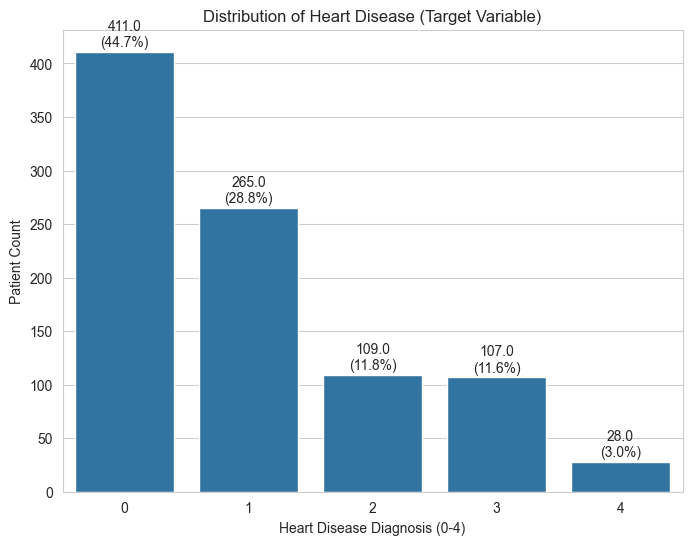

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df_raw, order=sorted(df_raw['num'].unique()))
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease Diagnosis (0-4)')
plt.ylabel('Patient Count')
total = len(df_raw)
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{height}\n({height/total:.1%})', ha="center")
plt.show()

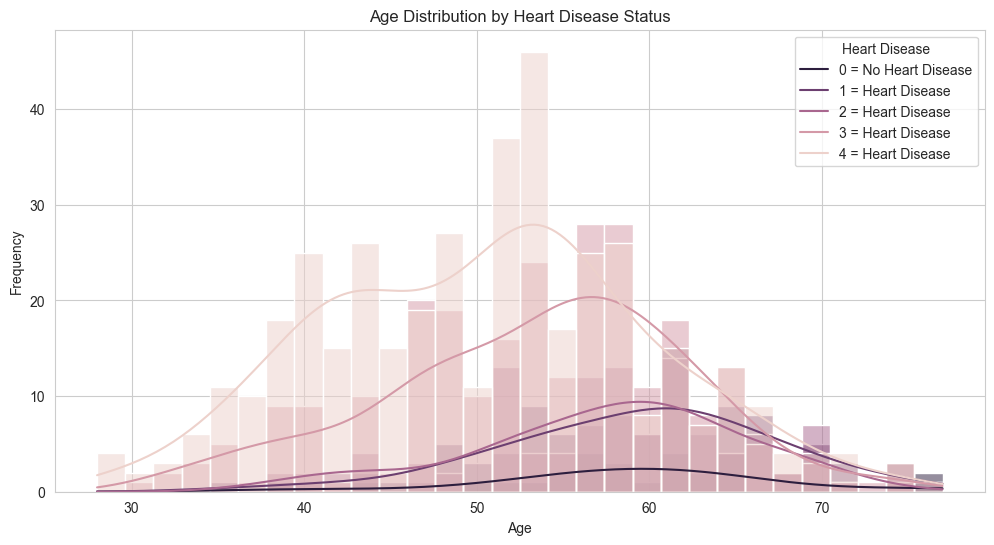

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='age', hue='num', kde=True, bins=30)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')

num_classes = sorted(df_raw['num'].unique())
labels = [f"{val} = {('No Heart Disease' if val == 0 else 'Heart Disease')}" for val in num_classes]
plt.legend(title='Heart Disease', labels=labels)
plt.show()